# Titanic Survival Analysis

## Objective
The objective of this project is to analyze passenger survival patterns from the Titanic dataset using Python data analysis and visualization libraries.

This analysis focuses on:
- Survival comparison by gender
- Survival comparison by passenger class
- Age distribution analysis
- Understanding important survival trends

## Tools & Technologies Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset
The dataset contains passenger information such as age, gender, class, fare, and survival status from the Titanic ship disaster.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Dataset Overview

In this section, we inspect the structure of the dataset including:
- Number of rows and columns
- Column data types
- Missing values
- Basic dataset information

In [4]:
df.shape

(891, 12)

In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Data Cleaning

The dataset contains missing values in some columns.  
For this analysis:
- Missing Age values are filled using the median age
- Duplicate rows are removed

In [7]:
df["Age"]= df["Age"].fillna(df["Age"].median())

In [8]:
df= df.drop_duplicates()

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Survival Analysis

This section analyzes passenger survival patterns based on:
- Gender
- Passenger class
- Age

In [10]:
gender_survival = df.groupby("Sex")["Survived"].mean()
print(gender_survival)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


# Survival by Passenger Class

This analysis checks whether passenger class affected survival chances.

In [11]:
class_survival= df.groupby("Pclass")["Survived"].mean()
print(class_survival)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


# Survival by Age Group

Passengers are divided into age groups to analyze survival trends across different age categories.

In [12]:
# Create age groups
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 12, 19, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

# Survival rate by age group
age_survival = df.groupby("Age_Group")["Survived"].mean()

print(age_survival)

Age_Group
Child          0.579710
Teen           0.410526
Young Adult    0.352941
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


C:\Users\rudra\AppData\Local\Temp\ipykernel_14584\674725794.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby("Age_Group")["Survived"].mean()


# Data Visualizations

Visualizations are used to better understand survival patterns and passenger demographics.

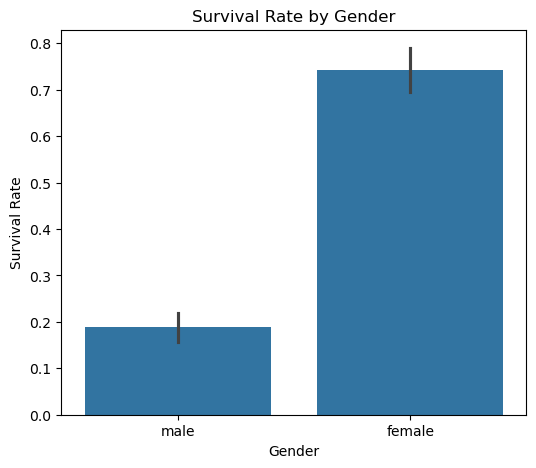

In [13]:
# Bar chart: Survival by gender
plt.figure(figsize=(6,5))

sns.barplot(x="Sex", y="Survived", data=df)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

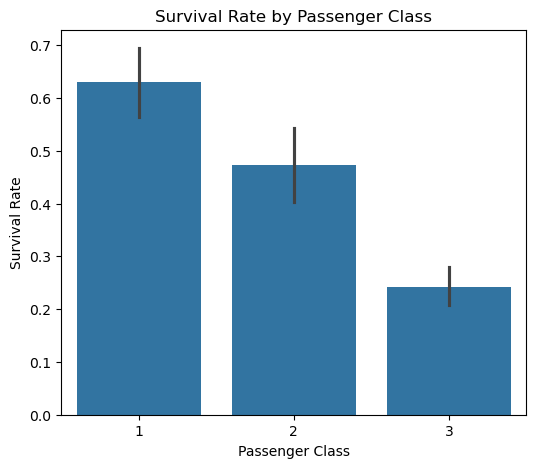

In [14]:
# Bar chart: Survival by passenger class
plt.figure(figsize=(6,5))

sns.barplot(x="Pclass", y="Survived", data=df)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

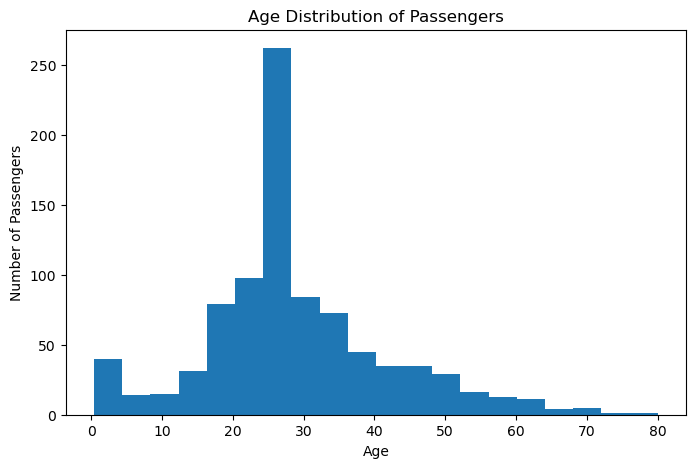

In [15]:
# Histogram of passenger ages
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

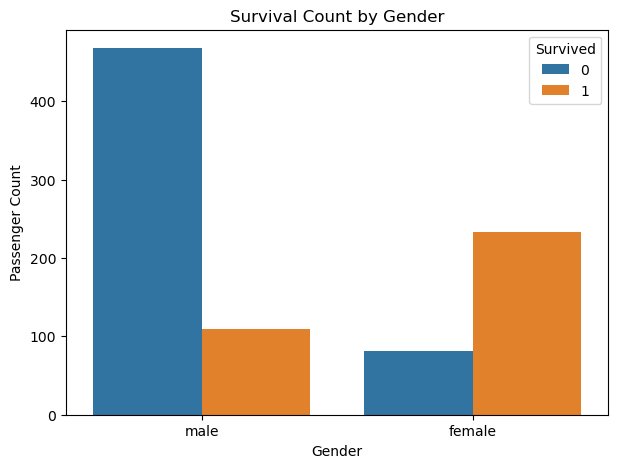

In [16]:
# Countplot of survival by gender
plt.figure(figsize=(7,5))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Passenger Count")

plt.show()

# Final Insights

## Key Findings
- Female passengers had a higher survival rate compared to males.
- Passengers in higher classes had better survival chances.
- Younger passengers showed relatively better survival patterns.
- Most passengers were young adults.

## Conclusion
The analysis shows that gender, passenger class, and age influenced survival outcomes during the Titanic disaster.